# Estabilidade temporal da letalidade por unidade federativa e por macrorregião

Quanto a ordenação da letalidade entre níveis geográficos persiste de um período para o outro, em duas granularidades: as 27 unidades federativas e as 5 macrorregiões.
A medida é feita inteiramente dentro do treino de 2020 a 2023, lido de `data/processed/dengue_treated_corrigida.parquet`, e o total é conferido contra a partição temporal gravada em `data/features/baseline/config.json`.
O teste de 2024 e a avaliação de 2025 não entram em nenhuma etapa, o que mantém a análise utilizável como justificativa da escolha de granularidade sem consultar a partição de avaliação.
Análise descritiva: nenhum modelo é treinado e nenhuma métrica de desempenho é calculada.

## Etapas
1. Agregar o treino ano a ano por unidade federativa e por macrorregião, liberando a memória de cada ano antes do seguinte.
2. Calcular a letalidade de cada unidade federativa nos quatro anos, marcando as células sustentadas por menos de dez óbitos.
3. Repetir a leitura por macrorregião.
4. Correlacionar a letalidade entre cada par de anos por Spearman, separando pares consecutivos de não consecutivos, nas duas granularidades.
5. Medir a razão entre a maior e a menor letalidade anual de cada nível, com os óbitos que sustentam cada extremo.
6. Contar os óbitos disponíveis por nível e quantos níveis ficam abaixo de cada limiar de eventos.
7. Dividir o treino em dois blocos de anos e correlacionar a letalidade de um bloco com a do outro.
8. Reunir as duas granularidades numa comparação direta e gravar as figuras.

## Entradas
- `data/processed/dengue_treated_corrigida.parquet`
- `data/features/baseline/config.json`

## Saídas
- `analysis/results_estabilidade_geografica/base_de_calculo.csv`
- `analysis/results_estabilidade_geografica/letalidade_por_uf_e_ano.csv`
- `analysis/results_estabilidade_geografica/letalidade_por_macrorregiao_e_ano.csv`
- `analysis/results_estabilidade_geografica/spearman_entre_anos_uf.csv`
- `analysis/results_estabilidade_geografica/spearman_entre_anos_macrorregiao.csv`
- `analysis/results_estabilidade_geografica/amplitude_anual_uf.csv`
- `analysis/results_estabilidade_geografica/amplitude_anual_macrorregiao.csv`
- `analysis/results_estabilidade_geografica/eventos_por_nivel.csv`
- `analysis/results_estabilidade_geografica/niveis_abaixo_do_limiar.csv`
- `analysis/results_estabilidade_geografica/letalidade_por_bloco_de_anos.csv`
- `analysis/results_estabilidade_geografica/spearman_entre_blocos_de_anos.csv`
- `analysis/results_estabilidade_geografica/comparacao_granularidades.csv`
- `analysis/plots/estabilidade_geografica/letalidade_por_uf.png`
- `analysis/plots/estabilidade_geografica/letalidade_por_macrorregiao.png`

Importações, caminhos, constantes e formatadores em português.

In [1]:
import gc
import json
import os
import re
import sys
import warnings
from itertools import combinations
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import spearmanr

# Raiz do repositorio por marcador estavel, e nao por contagem de niveis:
# reorganizar as pastas de notebooks deixa de quebrar os caminhos.
def _raiz_repo(inicio=None):
    d = os.path.abspath(inicio or os.getcwd())
    while not any(os.path.exists(os.path.join(d, m)) for m in ('pyproject.toml', '.git')):
        pai = os.path.dirname(d)
        if pai == d:
            raise RuntimeError(f'raiz do repositorio nao encontrada acima de {os.getcwd()}')
        d = pai
    return d

ROOT = _raiz_repo()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from utils import configuracoes
from utils.treat_data import MACRORREGIAO_POR_DIGITO

PROC_DIR     = os.path.join(ROOT, 'data', 'processed')
DIR_PARTICAO = os.path.join(ROOT, 'data', 'features', 'baseline')
DIR_TABELAS  = os.path.join(ROOT, 'analysis', 'results_estabilidade_geografica')
DIR_FIGURAS  = os.path.join(ROOT, 'analysis', 'plots', 'estabilidade_geografica')
for _d in (DIR_TABELAS, DIR_FIGURAS):
    os.makedirs(_d, exist_ok=True)

# Nenhuma etapa deste notebook sorteia nada: não há reamostragem, ajuste nem partição
# aleatória. A semente fica declarada por consistência com o restante do pipeline.
RANDOM_STATE = 42

CONFIG_COORTE = 'corrigida'
ANOS = [2020, 2021, 2022, 2023]
BLOCOS = {'2020-2021': [2020, 2021], '2022-2023': [2022, 2023]}

# Uma célula nível-ano é marcada quando a letalidade se apoia em menos de dez óbitos.
MIN_OBITOS_CELULA = 10
LIMIARES_EVENTOS = (10, 30, 100)

# Código do IBGE em SG_UF: sigla e nome. O primeiro dígito dá a macrorregião.
UF = {
    '11': ('RO', 'Rondônia'),            '12': ('AC', 'Acre'),
    '13': ('AM', 'Amazonas'),            '14': ('RR', 'Roraima'),
    '15': ('PA', 'Pará'),                '16': ('AP', 'Amapá'),
    '17': ('TO', 'Tocantins'),           '21': ('MA', 'Maranhão'),
    '22': ('PI', 'Piauí'),               '23': ('CE', 'Ceará'),
    '24': ('RN', 'Rio Grande do Norte'), '25': ('PB', 'Paraíba'),
    '26': ('PE', 'Pernambuco'),          '27': ('AL', 'Alagoas'),
    '28': ('SE', 'Sergipe'),             '29': ('BA', 'Bahia'),
    '31': ('MG', 'Minas Gerais'),        '32': ('ES', 'Espírito Santo'),
    '33': ('RJ', 'Rio de Janeiro'),      '35': ('SP', 'São Paulo'),
    '41': ('PR', 'Paraná'),              '42': ('SC', 'Santa Catarina'),
    '43': ('RS', 'Rio Grande do Sul'),   '50': ('MS', 'Mato Grosso do Sul'),
    '51': ('MT', 'Mato Grosso'),         '52': ('GO', 'Goiás'),
    '53': ('DF', 'Distrito Federal'),
}
CODIGOS_UF   = sorted(UF)
SIGLA        = {c: UF[c][0] for c in UF}
NOME_UF      = {c: UF[c][1] for c in UF}
# A tabela do IBGE e a ordem das macrorregiões vêm de utils/, e não de cópias locais:
# uma cópia que mudasse sozinha faria este notebook discordar em silêncio das bases.
MAPA_MACRO   = dict(MACRORREGIAO_POR_DIGITO)
MACRO_DA_UF  = {c: MAPA_MACRO[c[0]] for c in UF}
ORDEM_MACRO  = list(configuracoes.MACRORREGIOES)

# Paleta categórica validada para daltonismo nos cinco primeiros tons, na ordem fixa das
# macrorregiões. A cor identifica a macrorregião nas duas figuras; a identidade nunca
# depende só dela, porque toda linha recebe rótulo direto.
COR_MACRO = dict(zip(ORDEM_MACRO,
                     ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']))
COR_TINTA = '#52514e'
COR_LINHA_UF = '#9b9a95'

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.size': 9, 'axes.titlesize': 11, 'axes.labelsize': 9,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9c8c3', 'axes.labelcolor': '#52514e',
    'xtick.color': '#52514e', 'ytick.color': '#52514e', 'text.color': '#0b0b0b',
    'grid.color': '#e8e7e3', 'grid.linewidth': 0.8,
    'figure.facecolor': '#ffffff', 'axes.facecolor': '#ffffff', 'legend.frameon': False,
})


def n_(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return '-'
    return f'{int(x):,}'.replace(',', '.')


def v_(x, casas=3):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return '-'
    return f'{x:.{casas}f}'.replace('.', ',')


def pct_(x, casas=1):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return '-'
    return f'{x:.{casas}f}'.replace('.', ',') + '%'


def p_(x):
    return 'menor que 0,001' if x < 0.001 else v_(x, 3)


def par_(texto):
    '''Uma frase por linha, para o markdown ficar legível em diferença de versão.'''
    limpo = ' '.join(texto.split())
    return '\n'.join(re.split(r'(?<=[.:]) (?=[A-ZÀ-Ú])', limpo))


def eixo_pct(casas=0):
    return mpl.ticker.FuncFormatter(
        lambda x, pos=None: f'{x:.{casas}f}'.replace('.', ',') + '%')


def com_base(df):
    '''Todo arquivo carrega o N e o número de eventos do treino inteiro.'''
    d = df.copy()
    d['n_base_treino'] = N_TREINO
    d['eventos_treino'] = EVENTOS_TREINO
    return d


def salvar_tab(df, nome, index=False):
    caminho = os.path.join(DIR_TABELAS, nome)
    df.to_csv(caminho, index=index, encoding='utf-8')
    print(f'[tabela] {os.path.relpath(caminho, ROOT)}  ({len(df)} linhas)')
    return df


def salvar_fig(fig, nome):
    caminho = os.path.join(DIR_FIGURAS, nome)
    fig.savefig(caminho, dpi=300, bbox_inches='tight', facecolor='#ffffff')
    print(f'[figura] {os.path.relpath(caminho, ROOT)}')


print(f'Período: {ANOS[0]}-{ANOS[-1]} · granularidades: {len(UF)} unidades federativas e '
      f'{len(ORDEM_MACRO)} macrorregiões')
print(f'Marca de base insuficiente na célula: menos de {MIN_OBITOS_CELULA} óbitos · '
      f'semente {RANDOM_STATE}')

Período: 2020-2023 · granularidades: 27 unidades federativas e 5 macrorregiões
Marca de base insuficiente na célula: menos de 10 óbitos · semente 42


Única etapa que toca os dados: agrega o treino ano a ano, com as três colunas que a análise usa e a memória de cada ano liberada antes do seguinte, e grava as duas tabelas agregadas.

In [2]:
CAMINHO_COORTE = os.path.join(PROC_DIR, f'dengue_treated_{CONFIG_COORTE}.parquet')
COLUNAS_LIDAS = ['SG_UF', 'year', 'target']
ARQ_UF_ANO = 'letalidade_por_uf_e_ano.csv'
ARQ_MACRO_ANO = 'letalidade_por_macrorregiao_e_ano.csv'


def agregar_um_ano(ano):
    '''Lê um ano de cada vez, só as três colunas necessárias, devolve as 27 linhas
    agregadas por unidade federativa e libera o bloco bruto antes do ano seguinte.'''
    bruto = pd.read_parquet(CAMINHO_COORTE, engine='pyarrow', columns=COLUNAS_LIDAS,
                            filters=[('year', '==', ano)])
    assert set(bruto['year']) <= {ano}, 'o filtro de leitura trouxe outro ano'
    g = (bruto.loc[bruto['target'].notna()].groupby('SG_UF')['target']
         .agg(n_base='size', obitos='sum')
         .reindex(CODIGOS_UF).fillna(0).astype(int).reset_index())
    g.insert(0, 'ano', ano)
    del bruto
    gc.collect()
    return g


def agregados_por_uf_e_ano():
    '''Retoma da tabela agregada já gravada quando ela existe; só abre a base quando não
    existe. Ou de um jeito ou de outro, o que segue opera sobre as dezenas de linhas
    agregadas, nunca sobre os registros individuais.'''
    caminho = os.path.join(DIR_TABELAS, ARQ_UF_ANO)
    if os.path.exists(caminho):
        d = pd.read_csv(caminho, dtype={'SG_UF': str})
        print(f'Retomado de {os.path.relpath(caminho, ROOT)}: a base não foi aberta.')
        return d[['ano', 'SG_UF', 'n_base', 'obitos']].copy()
    partes = []
    for ano in ANOS:
        parte = agregar_um_ano(ano)
        print(f'{ano}: {n_(parte["n_base"].sum())} internações · '
              f'{n_(parte["obitos"].sum())} óbitos · '
              f'{int((parte["n_base"] > 0).sum())} unidades federativas com registro')
        partes.append(parte)
    return pd.concat(partes, ignore_index=True)


agregados = agregados_por_uf_e_ano()

with open(os.path.join(DIR_PARTICAO, 'config.json'), encoding='utf-8') as f:
    particao = json.load(f)

N_TREINO = int(agregados['n_base'].sum())
EVENTOS_TREINO = int(agregados['obitos'].sum())

assert particao['train_years'] == ANOS, 'a partição gravada não é a de 2020-2023'
assert N_TREINO == particao['train_size'], 'N do treino diferente do gravado na partição'
assert EVENTOS_TREINO == particao['train_events'], 'eventos do treino diferentes'
# Nenhum registro de 2024 ou 2025 entra em qualquer etapa deste notebook.
assert sorted(agregados['ano'].unique()) == ANOS, 'anos fora de 2020-2023 na base de cálculo'
assert set(agregados['SG_UF']) == set(CODIGOS_UF), 'código de UF fora da lista do IBGE'


def marcar(g):
    '''Letalidade da célula e a marca de base insuficiente. Combinação sem registro nenhum
    fica na tabela com n zero e letalidade indefinida, em vez de sumir dela.'''
    g = g.copy()
    g['letalidade_pct'] = np.where(g['n_base'] > 0,
                                   g['obitos'] / g['n_base'] * 100, np.nan).round(3)
    g['situacao'] = np.select(
        [g['n_base'] == 0, g['obitos'] < MIN_OBITOS_CELULA],
        ['sem registros', f'menos de {MIN_OBITOS_CELULA} óbitos'],
        default=f'{MIN_OBITOS_CELULA} óbitos ou mais')
    g['base_insuficiente'] = np.where(g['obitos'] < MIN_OBITOS_CELULA, 'sim', 'não')
    return g


df_uf_ano = marcar(
    agregados.set_index(['SG_UF', 'ano'])[['n_base', 'obitos']]
    .reindex(pd.MultiIndex.from_product([CODIGOS_UF, ANOS], names=['SG_UF', 'ano']))
    .fillna(0).astype(int).reset_index())
df_uf_ano.insert(1, 'sigla', df_uf_ano['SG_UF'].map(SIGLA))
df_uf_ano.insert(2, 'unidade_federativa', df_uf_ano['SG_UF'].map(NOME_UF))
df_uf_ano.insert(3, 'macrorregiao', df_uf_ano['SG_UF'].map(MACRO_DA_UF))
df_uf_ano = df_uf_ano[['SG_UF', 'sigla', 'unidade_federativa', 'macrorregiao', 'ano',
                       'n_base', 'obitos', 'letalidade_pct', 'situacao',
                       'base_insuficiente']]

# As macrorregiões somam as células anuais das suas unidades federativas: a base não é
# aberta uma segunda vez.
df_macro_ano = marcar(
    df_uf_ano.groupby(['macrorregiao', 'ano'])[['n_base', 'obitos']].sum()
    .reindex(pd.MultiIndex.from_product([ORDEM_MACRO, ANOS],
                                        names=['macrorregiao', 'ano']))
    .astype(int).reset_index())

salvar_tab(com_base(df_uf_ano), ARQ_UF_ANO)
salvar_tab(com_base(df_macro_ano), ARQ_MACRO_ANO)

print(f'\nTreino de {ANOS[0]} a {ANOS[-1]}: {n_(N_TREINO)} internações e '
      f'{n_(EVENTOS_TREINO)} óbitos ({pct_(EVENTOS_TREINO / N_TREINO * 100, 2)}), '
      f'conferido contra a partição de {particao["created_at"]}.')

2020: 26.320 internações · 486 óbitos · 27 unidades federativas com registro
2021: 13.777 internações · 226 óbitos · 26 unidades federativas com registro
2022: 42.211 internações · 891 óbitos · 26 unidades federativas com registro


2023: 44.766 internações · 1.021 óbitos · 27 unidades federativas com registro
[tabela] analysis/results_estabilidade_geografica/letalidade_por_uf_e_ano.csv  (108 linhas)
[tabela] analysis/results_estabilidade_geografica/letalidade_por_macrorregiao_e_ano.csv  (20 linhas)

Treino de 2020 a 2023: 127.074 internações e 2.624 óbitos (2,06%), conferido contra a partição de 2026-09-08.


Base de cálculo de cada ano e letalidade de cada unidade federativa nos quatro anos, com a marca das células sustentadas por menos de dez óbitos.

In [3]:
df_base = (df_uf_ano.groupby('ano')[['n_base', 'obitos']].sum().reset_index())
df_base['letalidade_pct'] = (df_base['obitos'] / df_base['n_base'] * 100).round(3)
com_registro = df_uf_ano[df_uf_ano['n_base'] > 0]
df_base['unidades_federativas_com_registro'] = [
    int((com_registro['ano'] == a).sum()) for a in df_base['ano']]
df_base['macrorregioes_com_registro'] = [
    int(com_registro.loc[com_registro['ano'] == a, 'macrorregiao'].nunique())
    for a in df_base['ano']]
salvar_tab(com_base(df_base), 'base_de_calculo.csv')
display(df_base)

CELULAS_UF = len(df_uf_ano)
SEM_REGISTRO_UF = int((df_uf_ano['situacao'] == 'sem registros').sum())
INSUF_UF = int(((df_uf_ano['base_insuficiente'] == 'sim') & (df_uf_ano['n_base'] > 0)).sum())

matriz_uf = df_uf_ano.pivot(index='sigla', columns='ano', values='letalidade_pct')
display(matriz_uf.round(2))
print(f'Células unidade federativa-ano: {CELULAS_UF} · sem registro nenhum: '
      f'{SEM_REGISTRO_UF} · com menos de {MIN_OBITOS_CELULA} óbitos: {INSUF_UF} de '
      f'{CELULAS_UF - SEM_REGISTRO_UF} com registro')
print('Sem registro: ' + ', '.join(
    f'{r["sigla"]} em {r["ano"]}'
    for _, r in df_uf_ano[df_uf_ano['situacao'] == 'sem registros'].iterrows()))

[tabela] analysis/results_estabilidade_geografica/base_de_calculo.csv  (4 linhas)


,ano,n_base,obitos,letalidade_pct,unidades_federativas_com_registro,macrorregioes_com_registro
0,2020,26320,486,1.847,27,5
1,2021,13777,226,1.640,26,5
2,2022,42211,891,2.111,26,5
3,2023,44766,1021,2.281,27,5


ano,2020,2021,2022,2023
sigla,,,,
AC,0.99,0.78,1.14,0.44
AL,0.00,2.48,0.71,1.09
AM,2.94,1.02,4.74,5.06
AP,0.00,0.00,0.00,0.00
BA,0.80,1.86,3.08,1.53
CE,0.88,1.10,1.24,1.02
DF,4.29,2.85,0.62,1.28
ES,0.00,NaN,NaN,2.54
GO,1.14,1.05,1.58,1.57


Células unidade federativa-ano: 108 · sem registro nenhum: 2 · com menos de 10 óbitos: 58 de 106 com registro
Sem registro: ES em 2021, ES em 2022


O mesmo por macrorregião.

In [4]:
CELULAS_MACRO = len(df_macro_ano)
SEM_REGISTRO_MACRO = int((df_macro_ano['situacao'] == 'sem registros').sum())
INSUF_MACRO = int(((df_macro_ano['base_insuficiente'] == 'sim')
                   & (df_macro_ano['n_base'] > 0)).sum())

matriz_macro = df_macro_ano.pivot(index='macrorregiao', columns='ano',
                                  values='letalidade_pct').loc[ORDEM_MACRO]
display(matriz_macro.round(2))
print(f'Células macrorregião-ano: {CELULAS_MACRO} · sem registro nenhum: '
      f'{SEM_REGISTRO_MACRO} · com menos de {MIN_OBITOS_CELULA} óbitos: {INSUF_MACRO}')
print(f'Menor número de óbitos numa célula: {int(df_macro_ano["obitos"].min())} '
      f'({df_macro_ano.loc[df_macro_ano["obitos"].idxmin(), "macrorregiao"]} em '
      f'{int(df_macro_ano.loc[df_macro_ano["obitos"].idxmin(), "ano"])})')

ano,2020,2021,2022,2023
macrorregiao,,,,
Norte,1.27,0.95,1.60,1.43
Nordeste,0.95,1.31,1.40,1.59
Sudeste,2.27,2.16,3.37,2.70
Sul,2.27,3.22,2.82,2.34
Centro-Oeste,1.55,1.40,1.37,1.56


Células macrorregião-ano: 20 · sem registro nenhum: 0 · com menos de 10 óbitos: 0
Menor número de óbitos numa célula: 15 (Norte em 2020)


Correlação de Spearman da letalidade entre cada par de anos, separando pares consecutivos de não consecutivos.

In [5]:
def spearman_entre_anos(df_long, chave, granularidade, niveis_totais):
    '''Um par de anos por linha. Entram só os níveis com registro nos dois anos do par,
    e o N de cada ano é o dos níveis efetivamente pareados.'''
    matriz = df_long.pivot(index=chave, columns='ano', values='letalidade_pct')
    contagens = df_long.set_index([chave, 'ano'])[['n_base', 'obitos']]
    linhas = []
    for a, b in combinations(ANOS, 2):
        par = matriz[[a, b]].dropna()
        rho, valor_p = spearmanr(par[a], par[b])
        totais = {ano: contagens.loc[[(nivel, ano) for nivel in par.index]].sum()
                  for ano in (a, b)}
        linhas.append({
            'granularidade': granularidade,
            'par_de_anos': f'{a}-{b}',
            'tipo_de_par': 'consecutivos' if b - a == 1 else 'não consecutivos',
            'distancia_em_anos': b - a,
            'spearman_rho': round(float(rho), 4),
            'valor_p': round(float(valor_p), 6),
            'niveis_com_dados_nos_dois_anos': len(par),
            'niveis_na_granularidade': niveis_totais,
            'n_base_ano_inicial': int(totais[a]['n_base']),
            'obitos_ano_inicial': int(totais[a]['obitos']),
            'n_base_ano_final': int(totais[b]['n_base']),
            'obitos_ano_final': int(totais[b]['obitos']),
        })
    return pd.DataFrame(linhas).sort_values(
        ['distancia_em_anos', 'par_de_anos']).reset_index(drop=True)


df_spearman_uf = spearman_entre_anos(df_uf_ano, 'SG_UF', 'unidade federativa', len(UF))
salvar_tab(com_base(df_spearman_uf), 'spearman_entre_anos_uf.csv')
display(df_spearman_uf[['par_de_anos', 'tipo_de_par', 'spearman_rho', 'valor_p',
                        'niveis_com_dados_nos_dois_anos', 'obitos_ano_inicial',
                        'obitos_ano_final']])

[tabela] analysis/results_estabilidade_geografica/spearman_entre_anos_uf.csv  (6 linhas)


,par_de_anos,tipo_de_par,spearman_rho,valor_p,niveis_com_dados_nos_dois_anos,obitos_ano_inicial,obitos_ano_final
0,2020-2021,consecutivos,0.1513,0.460784,26,486,226
1,2021-2022,consecutivos,0.4852,0.011987,26,226,891
2,2022-2023,consecutivos,0.3659,0.066036,26,891,943
3,2020-2022,não consecutivos,0.2938,0.145150,26,486,891
4,2021-2023,não consecutivos,0.2727,0.177643,26,226,943
5,2020-2023,não consecutivos,0.2450,0.218074,27,486,1021


O mesmo par a par entre as cinco macrorregiões.

In [6]:
df_spearman_macro = spearman_entre_anos(df_macro_ano, 'macrorregiao', 'macrorregião',
                                        len(ORDEM_MACRO))
salvar_tab(com_base(df_spearman_macro), 'spearman_entre_anos_macrorregiao.csv')
display(df_spearman_macro[['par_de_anos', 'tipo_de_par', 'spearman_rho', 'valor_p',
                           'niveis_com_dados_nos_dois_anos', 'obitos_ano_inicial',
                           'obitos_ano_final']])

for rotulo, d in (('unidade federativa', df_spearman_uf), ('macrorregião', df_spearman_macro)):
    consec = d[d['tipo_de_par'] == 'consecutivos']['spearman_rho']
    nao = d[d['tipo_de_par'] == 'não consecutivos']['spearman_rho']
    print(f'{rotulo:20s} consecutivos: mediana {v_(consec.median(), 3)} '
          f'[{v_(consec.min(), 3)}; {v_(consec.max(), 3)}] · não consecutivos: mediana '
          f'{v_(nao.median(), 3)} [{v_(nao.min(), 3)}; {v_(nao.max(), 3)}] · pares com p '
          f'abaixo de 0,05: {int((d["valor_p"] < 0.05).sum())} de {len(d)}')

[tabela] analysis/results_estabilidade_geografica/spearman_entre_anos_macrorregiao.csv  (6 linhas)


,par_de_anos,tipo_de_par,spearman_rho,valor_p,niveis_com_dados_nos_dois_anos,obitos_ano_inicial,obitos_ano_final
0,2020-2021,consecutivos,0.9,0.037386,5,486,226
1,2021-2022,consecutivos,0.5,0.391002,5,226,891
2,2022-2023,consecutivos,0.7,0.188120,5,891,1021
3,2020-2022,não consecutivos,0.6,0.284757,5,486,891
4,2021-2023,não consecutivos,0.8,0.104088,5,226,1021
5,2020-2023,não consecutivos,0.6,0.284757,5,486,1021


unidade federativa   consecutivos: mediana 0,366 [0,151; 0,485] · não consecutivos: mediana 0,273 [0,245; 0,294] · pares com p abaixo de 0,05: 1 de 6
macrorregião         consecutivos: mediana 0,700 [0,500; 0,900] · não consecutivos: mediana 0,600 [0,600; 0,800] · pares com p abaixo de 0,05: 1 de 6


Razão entre a maior e a menor letalidade anual de cada nível, com o número de óbitos que sustenta cada extremo.

In [7]:
def amplitude_anual(df_long, chave, granularidade):
    '''Extremos anuais de cada nível. A razão fica indefinida quando algum ano fecha com
    letalidade zero, e nesse caso a diferença em pontos percentuais é o que resta.'''
    linhas = []
    for nivel, g in df_long[df_long['n_base'] > 0].groupby(chave, sort=False):
        alto = g.loc[g['letalidade_pct'].idxmax()]
        baixo = g.loc[g['letalidade_pct'].idxmin()]
        tot = df_long[df_long[chave] == nivel][['n_base', 'obitos']].sum()
        definida = baixo['letalidade_pct'] > 0
        linhas.append({
            'granularidade': granularidade,
            'nivel': nivel,
            'anos_com_registro': len(g),
            'anos_com_10_obitos_ou_mais': int((g['obitos'] >= MIN_OBITOS_CELULA).sum()),
            'letalidade_maxima_pct': round(float(alto['letalidade_pct']), 3),
            'ano_da_maxima': int(alto['ano']),
            'obitos_no_ano_da_maxima': int(alto['obitos']),
            'n_base_no_ano_da_maxima': int(alto['n_base']),
            'letalidade_minima_pct': round(float(baixo['letalidade_pct']), 3),
            'ano_da_minima': int(baixo['ano']),
            'obitos_no_ano_da_minima': int(baixo['obitos']),
            'n_base_no_ano_da_minima': int(baixo['n_base']),
            'razao_maxima_minima': (round(float(alto['letalidade_pct']
                                                / baixo['letalidade_pct']), 3)
                                    if definida else np.nan),
            'razao_definida': 'sim' if definida else 'não, letalidade mínima igual a zero',
            'diferenca_pp': round(float(alto['letalidade_pct'] - baixo['letalidade_pct']), 3),
            'obitos_no_periodo': int(tot['obitos']),
            'n_base_no_periodo': int(tot['n_base']),
        })
    d = pd.DataFrame(linhas)
    return d.sort_values('razao_maxima_minima', ascending=False,
                         na_position='last').reset_index(drop=True)


df_amplitude_uf = amplitude_anual(df_uf_ano, 'sigla', 'unidade federativa')
df_amplitude_macro = amplitude_anual(df_macro_ano, 'macrorregiao', 'macrorregião')
salvar_tab(com_base(df_amplitude_uf), 'amplitude_anual_uf.csv')
salvar_tab(com_base(df_amplitude_macro), 'amplitude_anual_macrorregiao.csv')

colunas = ['nivel', 'letalidade_maxima_pct', 'ano_da_maxima', 'obitos_no_ano_da_maxima',
           'letalidade_minima_pct', 'ano_da_minima', 'obitos_no_ano_da_minima',
           'razao_maxima_minima', 'obitos_no_periodo']
display(df_amplitude_uf[colunas])
display(df_amplitude_macro[colunas])

for rotulo, d in (('unidade federativa', df_amplitude_uf),
                  ('macrorregião', df_amplitude_macro)):
    r = d['razao_maxima_minima'].dropna()
    print(f'{rotulo:20s} razão mediana {v_(r.median(), 2)}, faixa de {v_(r.min(), 2)} a '
          f'{v_(r.max(), 2)} · níveis sem razão definida: '
          f'{int(d["razao_maxima_minima"].isna().sum())} de {len(d)}')

[tabela] analysis/results_estabilidade_geografica/amplitude_anual_uf.csv  (27 linhas)
[tabela] analysis/results_estabilidade_geografica/amplitude_anual_macrorregiao.csv  (5 linhas)


,nivel,letalidade_maxima_pct,ano_da_maxima,obitos_no_ano_da_maxima,letalidade_minima_pct,ano_da_minima,obitos_no_ano_da_minima,razao_maxima_minima,obitos_no_periodo
0,DF,4.286,2020,36,0.616,2022,11,6.958,68
1,RJ,7.407,2020,6,1.350,2023,34,5.487,59
2,PB,4.098,2023,5,0.765,2022,7,5.357,17
3,AM,5.058,2023,13,1.018,2021,8,4.969,39
4,PE,2.400,2023,3,0.610,2020,1,3.934,12
5,BA,3.079,2022,27,0.805,2020,10,3.825,71
6,PA,1.534,2022,5,0.415,2023,1,3.696,10
7,RN,4.839,2020,6,1.724,2021,1,2.807,26
8,MG,2.624,2023,206,0.994,2020,16,2.640,283
9,AC,1.136,2022,2,0.441,2023,1,2.576,9


,nivel,letalidade_maxima_pct,ano_da_maxima,obitos_no_ano_da_maxima,letalidade_minima_pct,ano_da_minima,obitos_no_ano_da_minima,razao_maxima_minima,obitos_no_periodo
0,Norte,1.602,2022,43,0.947,2021,20,1.692,101
1,Nordeste,1.594,2023,70,0.951,2020,32,1.676,259
2,Sudeste,3.372,2022,315,2.157,2021,66,1.563,1102
3,Sul,3.215,2021,40,2.273,2020,167,1.414,683
4,Centro-Oeste,1.562,2023,111,1.366,2022,189,1.143,479


unidade federativa   razão mediana 2,58, faixa de 1,35 a 6,96 · níveis sem razão definida: 8 de 27
macrorregião         razão mediana 1,56, faixa de 1,14 a 1,69 · níveis sem razão definida: 0 de 5


Óbitos disponíveis em cada nível no treino inteiro e quantos níveis ficam abaixo de cada limiar de eventos.

In [8]:
def eventos_por_nivel(df_long, chave, granularidade):
    d = (df_long.groupby(chave, sort=False)[['n_base', 'obitos']].sum().reset_index()
         .rename(columns={chave: 'nivel'}))
    d.insert(0, 'granularidade', granularidade)
    d['letalidade_pct'] = (d['obitos'] / d['n_base'] * 100).round(3)
    for limiar in LIMIARES_EVENTOS:
        d[f'abaixo_de_{limiar}_obitos'] = np.where(d['obitos'] < limiar, 'sim', 'não')
    return d.sort_values('obitos').reset_index(drop=True)


df_eventos_uf = eventos_por_nivel(df_uf_ano, 'sigla', 'unidade federativa')
df_eventos_macro = eventos_por_nivel(df_macro_ano, 'macrorregiao', 'macrorregião')
salvar_tab(com_base(pd.concat([df_eventos_uf, df_eventos_macro], ignore_index=True)),
           'eventos_por_nivel.csv')

linhas = []
for granularidade, d in (('unidade federativa', df_eventos_uf),
                         ('macrorregião', df_eventos_macro)):
    for limiar in LIMIARES_EVENTOS:
        abaixo = d[d['obitos'] < limiar]
        linhas.append({
            'granularidade': granularidade,
            'limiar_de_obitos': limiar,
            'niveis_na_granularidade': len(d),
            'niveis_abaixo_do_limiar': len(abaixo),
            'pct_niveis_abaixo_do_limiar': round(len(abaixo) / len(d) * 100, 1),
            'obitos_no_menor_nivel': int(d['obitos'].min()),
            'nivel_com_menos_obitos': d.iloc[0]['nivel'],
            'obitos_no_maior_nivel': int(d['obitos'].max()),
            'niveis_citados': ', '.join(abaixo['nivel']) if len(abaixo) else '-',
        })
df_limiares = pd.DataFrame(linhas)
salvar_tab(com_base(df_limiares), 'niveis_abaixo_do_limiar.csv')
display(df_limiares[['granularidade', 'limiar_de_obitos', 'niveis_na_granularidade',
                     'niveis_abaixo_do_limiar', 'pct_niveis_abaixo_do_limiar',
                     'obitos_no_menor_nivel']])
display(df_eventos_uf[['nivel', 'n_base', 'obitos', 'letalidade_pct']])
display(df_eventos_macro[['nivel', 'n_base', 'obitos', 'letalidade_pct']])

[tabela] analysis/results_estabilidade_geografica/eventos_por_nivel.csv  (32 linhas)
[tabela] analysis/results_estabilidade_geografica/niveis_abaixo_do_limiar.csv  (6 linhas)


,granularidade,limiar_de_obitos,niveis_na_granularidade,niveis_abaixo_do_limiar,pct_niveis_abaixo_do_limiar,obitos_no_menor_nivel
0,unidade federativa,10,27,3,11.1,0
1,unidade federativa,30,27,13,48.1,0
2,unidade federativa,100,27,20,74.1,0
3,macrorregião,10,5,0,0.0,101
4,macrorregião,30,5,0,0.0,101
5,macrorregião,100,5,0,0.0,101


,nivel,n_base,obitos,letalidade_pct
0,AP,133,0,0.000
1,RR,51,2,3.922
2,AC,1093,9,0.823
3,PA,967,10,1.034
4,PE,940,12,1.277
5,TO,1645,15,0.912
6,PB,1312,17,1.296
7,AL,1538,17,1.105
8,PI,2374,18,0.758
9,SE,875,21,2.400


,nivel,n_base,obitos,letalidade_pct
0,Norte,7579,101,1.333
1,Nordeste,19203,259,1.349
2,Centro-Oeste,32871,479,1.457
3,Sul,27250,683,2.506
4,Sudeste,40171,1102,2.743


Divide o treino nos blocos de 2020-2021 e 2022-2023, somando as células anuais já agregadas, e correlaciona a letalidade de um bloco com a do outro. A divisão em blocos aproxima a estrutura da validação temporal usando apenas dados de treino, sem consultar 2024 nem 2025.

In [9]:
NOMES_BLOCO = list(BLOCOS)


def letalidade_por_bloco(df_long, chave, niveis, granularidade):
    '''Soma as células anuais dentro de cada bloco. As tabelas agregadas bastam: a base
    não é aberta de novo.'''
    d = df_long[[chave, 'ano', 'n_base', 'obitos']].copy()
    d['bloco'] = np.where(d['ano'].isin(BLOCOS[NOMES_BLOCO[0]]),
                          NOMES_BLOCO[0], NOMES_BLOCO[1])
    g = (d.groupby([chave, 'bloco'])[['n_base', 'obitos']].sum()
         .reindex(pd.MultiIndex.from_product([niveis, NOMES_BLOCO],
                                             names=[chave, 'bloco']))
         .fillna(0).astype(int).reset_index())
    g['letalidade_pct'] = np.where(g['n_base'] > 0,
                                   g['obitos'] / g['n_base'] * 100, np.nan).round(3)
    g['base_insuficiente'] = np.where(g['obitos'] < MIN_OBITOS_CELULA, 'sim', 'não')
    g.insert(0, 'granularidade', granularidade)
    g = g.rename(columns={chave: 'nivel'})
    g['posicao_no_bloco'] = (g.groupby('bloco')['letalidade_pct']
                             .rank(ascending=False, method='min'))
    return g


df_bloco_uf = letalidade_por_bloco(df_uf_ano, 'sigla', [SIGLA[c] for c in CODIGOS_UF],
                                   'unidade federativa')
df_bloco_macro = letalidade_por_bloco(df_macro_ano, 'macrorregiao', ORDEM_MACRO,
                                      'macrorregião')
salvar_tab(com_base(pd.concat([df_bloco_uf, df_bloco_macro], ignore_index=True)),
           'letalidade_por_bloco_de_anos.csv')

linhas = []
for granularidade, d, total in (('unidade federativa', df_bloco_uf, len(UF)),
                                ('macrorregião', df_bloco_macro, len(ORDEM_MACRO))):
    matriz = d.pivot(index='nivel', columns='bloco', values='letalidade_pct').dropna()
    rho, valor_p = spearmanr(matriz[NOMES_BLOCO[0]], matriz[NOMES_BLOCO[1]])
    soma = d[d['nivel'].isin(matriz.index)].groupby('bloco')[['n_base', 'obitos']].sum()
    linhas.append({
        'granularidade': granularidade,
        'bloco_inicial': NOMES_BLOCO[0], 'bloco_final': NOMES_BLOCO[1],
        'spearman_rho': round(float(rho), 4),
        'valor_p': round(float(valor_p), 6),
        'niveis_com_dados_nos_dois_blocos': len(matriz),
        'niveis_na_granularidade': total,
        'n_base_bloco_inicial': int(soma.loc[NOMES_BLOCO[0], 'n_base']),
        'obitos_bloco_inicial': int(soma.loc[NOMES_BLOCO[0], 'obitos']),
        'n_base_bloco_final': int(soma.loc[NOMES_BLOCO[1], 'n_base']),
        'obitos_bloco_final': int(soma.loc[NOMES_BLOCO[1], 'obitos']),
        'niveis_com_menos_de_10_obitos_em_algum_bloco': int(
            d[d['nivel'].isin(matriz.index)]
            .groupby('nivel')['base_insuficiente'].apply(lambda s: (s == 'sim').any()).sum()),
    })
df_blocos = pd.DataFrame(linhas)
salvar_tab(com_base(df_blocos), 'spearman_entre_blocos_de_anos.csv')
display(df_blocos[['granularidade', 'spearman_rho', 'valor_p',
                   'niveis_com_dados_nos_dois_blocos',
                   'niveis_com_menos_de_10_obitos_em_algum_bloco']])
display(df_bloco_macro[['nivel', 'bloco', 'n_base', 'obitos', 'letalidade_pct',
                        'posicao_no_bloco']])

[tabela] analysis/results_estabilidade_geografica/letalidade_por_bloco_de_anos.csv  (64 linhas)
[tabela] analysis/results_estabilidade_geografica/spearman_entre_blocos_de_anos.csv  (2 linhas)


,granularidade,spearman_rho,valor_p,niveis_com_dados_nos_dois_blocos,niveis_com_menos_de_10_obitos_em_algum_bloco
0,unidade federativa,0.5141,0.006081,27,16
1,macrorregião,0.5000,0.391002,5,0


,nivel,bloco,n_base,obitos,letalidade_pct,posicao_no_bloco
0,Norte,2020-2021,3290,35,1.064,5.0
1,Norte,2022-2023,4289,66,1.539,3.0
2,Nordeste,2020-2021,6578,74,1.125,4.0
3,Nordeste,2022-2023,12625,185,1.465,4.0
4,Sudeste,2020-2021,9708,217,2.235,2.0
5,Sudeste,2022-2023,30463,885,2.905,1.0
6,Sul,2020-2021,8590,207,2.410,1.0
7,Sul,2022-2023,18660,476,2.551,2.0
8,Centro-Oeste,2020-2021,11931,179,1.500,3.0
9,Centro-Oeste,2022-2023,20940,300,1.433,5.0


Reúne as duas granularidades numa comparação direta: persistência da ordenação, base disponível por nível e amplitude da variação anual.

In [10]:
def resumo_granularidade(d_spearman, d_bloco, d_eventos, d_amplitude, celulas, sem_registro,
                         insuficientes, n_niveis):
    consec = d_spearman[d_spearman['tipo_de_par'] == 'consecutivos']['spearman_rho']
    nao = d_spearman[d_spearman['tipo_de_par'] == 'não consecutivos']['spearman_rho']
    todos = d_spearman['spearman_rho']
    razao = d_amplitude['razao_maxima_minima'].dropna()
    b = d_bloco.iloc[0]
    return {
        'Níveis na granularidade': n_(n_niveis),
        'Células nível-ano': n_(celulas),
        'Células sem registro nenhum': n_(sem_registro),
        f'Células com menos de {MIN_OBITOS_CELULA} óbitos':
            f'{n_(insuficientes)} de {n_(celulas - sem_registro)}',
        'Spearman entre anos consecutivos, mediana': v_(consec.median(), 3),
        'Spearman entre anos consecutivos, faixa':
            f'{v_(consec.min(), 3)} a {v_(consec.max(), 3)}',
        'Spearman entre anos não consecutivos, mediana': v_(nao.median(), 3),
        'Spearman entre anos não consecutivos, faixa':
            f'{v_(nao.min(), 3)} a {v_(nao.max(), 3)}',
        'Spearman entre todos os pares de anos, mediana': v_(todos.median(), 3),
        'Pares de anos com p abaixo de 0,05':
            f'{int((d_spearman["valor_p"] < 0.05).sum())} de {len(d_spearman)}',
        'Spearman entre os blocos 2020-2021 e 2022-2023': v_(b['spearman_rho'], 3),
        'Valor p entre os blocos': p_(b['valor_p']),
        **{f'Níveis com menos de {lim} óbitos no treino':
           f'{int((d_eventos["obitos"] < lim).sum())} de {n_niveis}'
           for lim in LIMIARES_EVENTOS},
        'Óbitos no nível com menos eventos': n_(d_eventos['obitos'].min()),
        'Óbitos no nível com mais eventos': n_(d_eventos['obitos'].max()),
        'Razão entre maior e menor letalidade anual, mediana': v_(razao.median(), 2),
        'Razão entre maior e menor letalidade anual, máxima': v_(razao.max(), 2),
        'Níveis com razão não definida':
            f'{int(d_amplitude["razao_maxima_minima"].isna().sum())} de {n_niveis}',
    }


resumo_uf = resumo_granularidade(df_spearman_uf, df_blocos[df_blocos['granularidade']
                                 == 'unidade federativa'], df_eventos_uf, df_amplitude_uf,
                                 CELULAS_UF, SEM_REGISTRO_UF, INSUF_UF, len(UF))
resumo_macro = resumo_granularidade(df_spearman_macro, df_blocos[df_blocos['granularidade']
                                    == 'macrorregião'], df_eventos_macro, df_amplitude_macro,
                                    CELULAS_MACRO, SEM_REGISTRO_MACRO, INSUF_MACRO,
                                    len(ORDEM_MACRO))

df_comparacao = pd.DataFrame({
    'indicador': list(resumo_uf),
    'unidade_federativa': [resumo_uf[k] for k in resumo_uf],
    'macrorregiao': [resumo_macro[k] for k in resumo_uf],
})
salvar_tab(com_base(df_comparacao), 'comparacao_granularidades.csv')
display(df_comparacao)

[tabela] analysis/results_estabilidade_geografica/comparacao_granularidades.csv  (20 linhas)


,indicador,unidade_federativa,macrorregiao
0,Níveis na granularidade,27,5
1,Células nível-ano,108,20
2,Células sem registro nenhum,2,0
3,Células com menos de 10 óbitos,58 de 106,0 de 20
4,"Spearman entre anos consecutivos, mediana","0,366","0,700"
5,"Spearman entre anos consecutivos, faixa","0,151 a 0,485","0,500 a 0,900"
6,"Spearman entre anos não consecutivos, mediana","0,273","0,600"
7,"Spearman entre anos não consecutivos, faixa","0,245 a 0,294","0,600 a 0,800"
8,"Spearman entre todos os pares de anos, mediana","0,283","0,650"
9,"Pares de anos com p abaixo de 0,05",1 de 6,1 de 6


Letalidade de cada unidade federativa ao longo dos quatro anos, em um painel por macrorregião, com a letalidade da macrorregião sobreposta.

[figura] analysis/plots/estabilidade_geografica/letalidade_por_uf.png


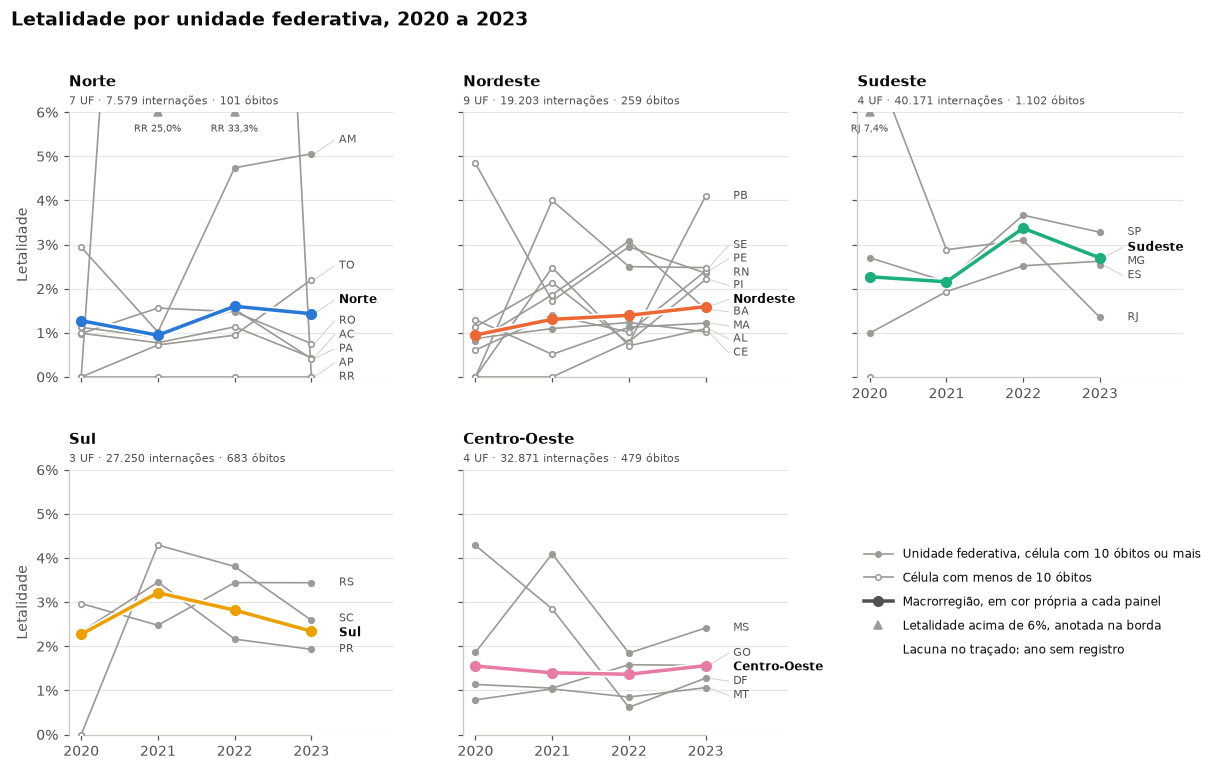

In [11]:
POS = {ano: i for i, ano in enumerate(ANOS)}
# Teto do eixo: a maior letalidade entre as células sustentadas por dez óbitos ou mais.
# As poucas células acima dele vêm de bases de um dígito e são anotadas na borda.
LIMITE_Y = float(np.ceil(
    df_uf_ano.loc[df_uf_ano['obitos'] >= MIN_OBITOS_CELULA, 'letalidade_pct'].max()))
X_FIM = len(ANOS) - 1


def separar_rotulos(valores, folga, minimo=None, maximo=None):
    '''Afasta na vertical os rótulos que se sobreporiam. Cada grupo em conflito é centrado no
    próprio ponto médio, para o deslocamento ficar repartido entre os rótulos do grupo.'''
    v = np.asarray(valores, dtype=float)
    ordem = np.argsort(v)
    s = v[ordem].copy()
    for _ in range(24):
        movido, i = False, 0
        while i < len(s):
            j = i
            while j + 1 < len(s) and s[j + 1] - s[j] < folga - 1e-9:
                j += 1
            if j > i:
                s[i:j + 1] = (s[i:j + 1].mean() - folga * (j - i) / 2
                              + folga * np.arange(j - i + 1))
                movido = True
            i = j + 1
        if not movido:
            break
    if minimo is not None:
        s = s + max(0.0, minimo - s[0])
    if maximo is not None and s[-1] > maximo:
        s = s - (s[-1] - maximo)
    saida = np.empty_like(s)
    saida[ordem] = s
    return saida


def linha_de_nivel(ax, d, cor, largura, tamanho_marca, zorder, halo=False):
    '''Uma série anual. Ano sem registro vira lacuna, para o traçado não sugerir observação
    onde não há; marca cheia quando a célula tem dez óbitos ou mais, vazada quando tem
    menos. Devolve o último ponto observado, que ancora o rótulo direto.'''
    d = d.set_index('ano').reindex(ANOS).reset_index()
    x = np.array([POS[a] for a in d['ano']], dtype=float)
    y = d['letalidade_pct'].where(d['n_base'].fillna(0) > 0)
    efeitos = [pe.Stroke(linewidth=largura + 2.2, foreground='#ffffff'), pe.Normal()]
    ax.plot(x, y, color=cor, linewidth=largura, solid_capstyle='round', zorder=zorder,
            path_effects=efeitos if halo else None)
    cheia = (d['obitos'].fillna(0) >= MIN_OBITOS_CELULA) & y.notna()
    vazada = y.notna() & ~cheia
    for marcador, cor_face in ((cheia, cor), (vazada, '#ffffff')):
        ax.plot(x[marcador.to_numpy()], y[marcador], linestyle='none', marker='o',
                markersize=tamanho_marca, markerfacecolor=cor_face, markeredgecolor=cor,
                markeredgewidth=1.1, zorder=zorder + 1)
    observados = y.dropna()
    return float(x[observados.index[-1]]), float(observados.iloc[-1])


def rotular_pontas(ax, pontas, folga, teto, destaque=None):
    '''Rótulo direto na ponta de cada série, com linha de chamada quando ele precisou sair
    da altura do próprio ponto.'''
    alvos = separar_rotulos([y for _, y, _ in pontas], folga, minimo=0.0, maximo=teto)
    for (x0, y0, rotulo), alvo in zip(pontas, alvos):
        marcado = rotulo == destaque
        if abs(alvo - y0) > folga * 0.12:
            ax.plot([x0 + 0.04, X_FIM + 0.30], [y0, alvo], color='#d5d4cf',
                    linewidth=0.7, zorder=1)
        ax.text(X_FIM + 0.36, alvo, rotulo, va='center', ha='left',
                fontsize=8 if marcado else 6.9,
                color='#0b0b0b' if marcado else COR_TINTA,
                fontweight='bold' if marcado else 'normal')


def painel_macrorregiao(ax, regiao, com_rotulo_x, com_rotulo_y):
    pontas = []
    for sigla in [SIGLA[c] for c in CODIGOS_UF if MACRO_DA_UF[c] == regiao]:
        x0, y0 = linha_de_nivel(ax, df_uf_ano[df_uf_ano['sigla'] == sigla], COR_LINHA_UF,
                                1.1, 3.6, zorder=2)
        pontas.append((x0, min(y0, LIMITE_Y), sigla))
    x0, y0 = linha_de_nivel(ax, df_macro_ano[df_macro_ano['macrorregiao'] == regiao],
                            COR_MACRO[regiao], 2.3, 6.2, zorder=6, halo=True)
    pontas.append((x0, y0, regiao))
    rotular_pontas(ax, pontas, folga=LIMITE_Y * 0.053, teto=LIMITE_Y, destaque=regiao)

    for _, r in df_uf_ano[(df_uf_ano['macrorregiao'] == regiao)
                          & (df_uf_ano['letalidade_pct'] > LIMITE_Y)].iterrows():
        ax.plot(POS[r['ano']], LIMITE_Y, marker='^', markersize=5, color=COR_LINHA_UF,
                zorder=7)
        ax.text(POS[r['ano']], LIMITE_Y * 0.955, f'{r["sigla"]} {pct_(r["letalidade_pct"], 1)}',
                ha='center', va='top', fontsize=6.4, color=COR_TINTA)

    d = df_macro_ano[df_macro_ano['macrorregiao'] == regiao]
    n_ufs = sum(1 for c in CODIGOS_UF if MACRO_DA_UF[c] == regiao)
    ax.set_title(regiao, loc='left', fontsize=10, fontweight='bold', pad=17)
    ax.text(0, 1.02, f'{n_ufs} UF · {n_(d["n_base"].sum())} internações · '
            f'{n_(d["obitos"].sum())} óbitos', transform=ax.transAxes, ha='left',
            va='bottom', fontsize=7, color=COR_TINTA)
    ax.set_xlim(-0.16, X_FIM + 1.08)
    ax.set_ylim(0, LIMITE_Y)
    ax.set_xticks(list(POS.values()))
    ax.set_xticklabels(ANOS if com_rotulo_x else [])
    ax.set_yticks(np.arange(0, LIMITE_Y + 0.5, 1))
    ax.yaxis.set_major_formatter(eixo_pct())
    # O eixo horizontal para em 2023: prolongá-lo pela calha dos rótulos sugeriria
    # um quinto ano que não existe.
    ax.spines['bottom'].set_bounds(0, X_FIM)
    ax.grid(True, axis='y')
    ax.set_axisbelow(True)
    if com_rotulo_y:
        ax.set_ylabel('Letalidade')


fig, eixos = plt.subplots(2, 3, figsize=(11.4, 6.8), sharey=True)
for i, regiao in enumerate(ORDEM_MACRO):
    painel_macrorregiao(eixos.flat[i], regiao, com_rotulo_x=i >= 2, com_rotulo_y=i % 3 == 0)
eixos.flat[-1].axis('off')
eixos.flat[-1].legend(handles=[
    Line2D([], [], color=COR_LINHA_UF, linewidth=1.1, marker='o', markersize=3.6,
           label=f'Unidade federativa, célula com {MIN_OBITOS_CELULA} óbitos ou mais'),
    Line2D([], [], color=COR_LINHA_UF, linewidth=1.1, marker='o', markersize=3.6,
           markerfacecolor='#ffffff', label=f'Célula com menos de {MIN_OBITOS_CELULA} óbitos'),
    Line2D([], [], color=COR_TINTA, linewidth=2.3, marker='o', markersize=6.2,
           label='Macrorregião, em cor própria a cada painel'),
    Line2D([], [], color=COR_LINHA_UF, linewidth=0, marker='^', markersize=5,
           label=f'Letalidade acima de {pct_(LIMITE_Y, 0)}, anotada na borda'),
    Line2D([], [], color='#ffffff', linewidth=0,
           label='Lacuna no traçado: ano sem registro'),
], loc='center left', fontsize=8, handlelength=2.4, borderpad=0, labelspacing=0.9)
fig.suptitle('Letalidade por unidade federativa, 2020 a 2023', x=0.008, y=1.02,
             ha='left', fontsize=12.5, fontweight='bold')
fig.tight_layout(w_pad=2.0, h_pad=3.4)
salvar_fig(fig, 'letalidade_por_uf.png')
plt.show()

A mesma leitura nas cinco macrorregiões, em um painel único.

[figura] analysis/plots/estabilidade_geografica/letalidade_por_macrorregiao.png


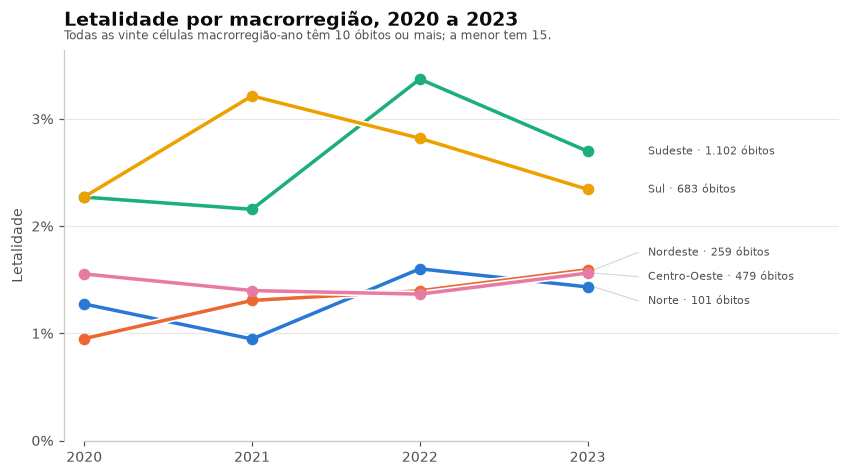

In [12]:
fig, ax = plt.subplots(figsize=(7.8, 4.4))
teto = float(df_macro_ano['letalidade_pct'].max()) * 1.08
pontas = []
for regiao in ORDEM_MACRO:
    d = df_macro_ano[df_macro_ano['macrorregiao'] == regiao]
    x0, y0 = linha_de_nivel(ax, d, COR_MACRO[regiao], 2.3, 6.5, zorder=4, halo=True)
    pontas.append((x0, y0, f'{regiao} · {n_(d["obitos"].sum())} óbitos'))
rotular_pontas(ax, pontas, folga=teto * 0.062, teto=teto)

ax.set_xlim(-0.12, X_FIM + 1.5)
ax.set_ylim(0, teto)
ax.set_xticks(list(POS.values()))
ax.set_xticklabels(ANOS)
ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(1))
ax.yaxis.set_major_formatter(eixo_pct())
ax.spines['bottom'].set_bounds(0, X_FIM)
ax.grid(True, axis='y')
ax.set_axisbelow(True)
ax.set_ylabel('Letalidade')
ax.set_title('Letalidade por macrorregião, 2020 a 2023', loc='left', fontsize=12.5,
             fontweight='bold', pad=16)
ax.text(0, 1.02, f'Todas as vinte células macrorregião-ano têm {MIN_OBITOS_CELULA} óbitos '
        f'ou mais; a menor tem {int(df_macro_ano["obitos"].min())}.',
        transform=ax.transAxes, ha='left', va='bottom', fontsize=7.6, color=COR_TINTA)
fig.tight_layout()
salvar_fig(fig, 'letalidade_por_macrorregiao.png')
plt.show()

## Conclusões

- O treino de 2020 a 2023 reúne 127.074 internações e 2.624 óbitos, 2,1% de letalidade, distribuídos em 27 unidades federativas e 5 macrorregiões.

- A correlação de Spearman da letalidade por unidade federativa entre anos consecutivos é de 0,151 em 2020-2021, 0,485 em 2021-2022 e 0,366 em 2022-2023, com mediana de 0,366. Só o par 2021-2022 tem valor p abaixo de 0,05, em 0,012.

- Entre anos não consecutivos a correlação por unidade federativa vai de 0,245 a 0,294, com mediana de 0,273, e nenhum dos três pares tem valor p abaixo de 0,05.

- Entre as cinco macrorregiões a correlação vai de 0,500 a 0,900 nos pares consecutivos, com mediana de 0,700, e de 0,600 a 0,800 nos não consecutivos, com mediana de 0,600. Um dos seis pares tem valor p abaixo de 0,05: 2020-2021, com 0,900 e valor p de 0,037.

- No conjunto dos seis pares de anos a mediana da correlação é de 0,650 na macrorregião contra 0,283 na unidade federativa. O menor valor observado na macrorregião, 0,500, é maior que o maior valor observado na unidade federativa, 0,485.

- Entre os blocos de 2020-2021 e 2022-2023 as duas granularidades praticamente empatam: 0,514 nas 27 unidades federativas e 0,500 nas 5 macrorregiões. O valor p difere, 0,006 contra 0,391, porque um teste ordena 27 níveis e o outro, 5.

- Na divisão em blocos as macrorregiões trocam de posição: Sul e Sudeste alternam a primeira, o Norte sobe da quinta para a terceira, o Centro-Oeste cai da terceira para a quinta e o Nordeste fica na quarta nos dois blocos. A letalidade de Sul e Sudeste fica entre 2,2% e 2,9% nos dois blocos, e a das outras três entre 1,1% e 1,5%.

- Das 108 células unidade federativa-ano, 2 não têm registro nenhum, as do Espírito Santo em 2021 e 2022, e 58 das 106 restantes se apoiam em menos de 10 óbitos. Nas 20 células macrorregião-ano nenhuma fica abaixo desse número, e a menor tem 15 óbitos, o Norte em 2020.

- No treino inteiro, 3 das 27 unidades federativas ficam abaixo de 10 óbitos, 13 abaixo de 30 e 20 abaixo de 100. O Amapá fecha os quatro anos sem nenhum óbito e Roraima com 2, em 51 internações. Nenhuma das cinco macrorregiões fica abaixo de qualquer um dos três limiares, e a menor delas, o Norte, tem 101 óbitos.

- A razão entre a maior e a menor letalidade anual tem mediana de 2,58 entre as unidades federativas, chega a 6,96 no Distrito Federal e fica indefinida em 8 das 27, que fecham pelo menos um ano com letalidade zero. Entre as macrorregiões a mediana é de 1,56, o máximo é de 1,69 no Norte e nenhuma tem a razão indefinida.

- As maiores razões por unidade federativa se apoiam em poucos eventos. No Distrito Federal a mínima de 0,6% vem de 11 óbitos e a máxima de 4,3% vem de 36. No Rio de Janeiro a máxima de 7,4% vem de 6 óbitos em 81 internações. Na Paraíba os dois extremos, 4,1% e 0,8%, somam 12 óbitos.